# CCP Multiclass Semantic Segmentation Benchmark

This notebook approaches the Clothing Co-Parsing (CCP) problem as a multiclass semantic segmentation task. We will:
1.  Benchmark different architectures (Unet, FPN, DeepLabV3+) using a fixed encoder.
2.  Apply Test Time Augmentation (TTA) to the best model.
3.  Analyze the results.

In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as BaseDataset
import albumentations as albu
import segmentation_models_pytorch as smp
import tqdm

DATA_DIR = './clothes'
CLASS_DICT_PATH = os.path.join(DATA_DIR, 'class_dict.csv')

# Check device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## Data Preparation

First, we load the class dictionary to understand the mapping from RGB values to class labels.

Total classes: 59
Precomputing RGB to Mask lookup table...


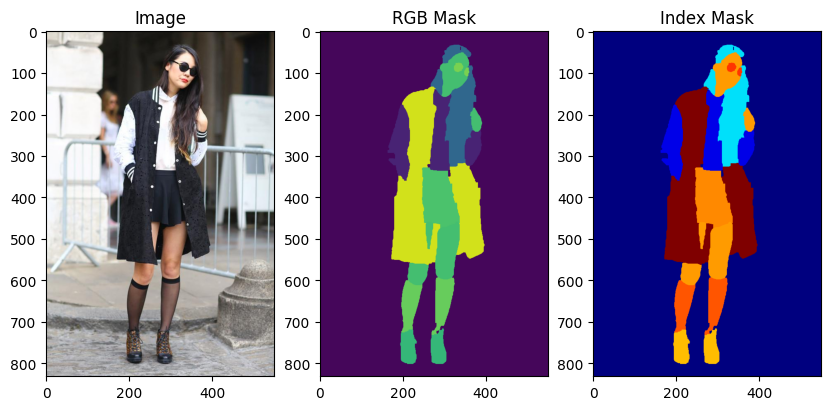

In [6]:
class_df = pd.read_csv(CLASS_DICT_PATH)
class_names = class_df['class_name'].tolist()
class_rgb_values = class_df[['r', 'g', 'b']].values.tolist()

print(f'Total classes: {len(class_names)}')

# Precompute lookup table for faster mask conversion
# We map RGB to a single integer: R << 16 | G << 8 | B
print("Precomputing RGB to Mask lookup table...")
lookup_table = np.zeros(256**3, dtype=np.int32)
for idx, (r, g, b) in enumerate(class_rgb_values):
    key = (r << 16) | (g << 8) | b
    lookup_table[key] = idx

# Helper function to convert RGB mask to 1D index mask
def rgb_to_mask(rgb_image, colormap=None):
    """
    Convert an RGB image to a mask using a precomputed lookup table.
    
    Args:
        rgb_image: H x W x 3 array, RGB image.
        colormap: Unused in optimized version, kept for compatibility.
        
    Returns:
        H x W mask with class indices.
    """
    # Convert RGB to single integer keys
    # Ensure int32 to prevent overflow during bit shifting
    rgb = rgb_image.astype(np.int32)
    keys = (rgb[:, :, 0] << 16) | (rgb[:, :, 1] << 8) | rgb[:, :, 2]

    # Direct lookup
    output_mask = lookup_table[keys]

    return output_mask.astype(np.int32)

# Let's visualize one example
test_img_path = os.path.join(DATA_DIR, 'train/images/0001.jpg')
test_mask_path = os.path.join(DATA_DIR, 'train/labels/0001.png')

if os.path.exists(test_img_path):
    img = cv2.imread(test_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(test_mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    
    converted_mask = rgb_to_mask(mask, class_rgb_values)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Image')
    plt.subplot(1, 3, 2)
    plt.imshow(mask)
    plt.title('RGB Mask')
    plt.subplot(1, 3, 3)
    plt.imshow(converted_mask, cmap='jet')
    plt.title('Index Mask')
    plt.show()

## Dataset Class

In [7]:
class CCPDataset(BaseDataset):
    def __init__(self, images_dir, masks_dir, class_rgb_values, augmentation=None, preprocessing=None):
        self.ids = sorted(os.listdir(images_dir))
        self.images_fps = [os.path.join(images_dir, image_id) for image_id in self.ids]
        self.masks_fps = [os.path.join(masks_dir, image_id.replace('.jpg', '.png')) for image_id in self.ids]
        self.class_rgb_values = class_rgb_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing
    
    def __getitem__(self, i):
        # read data
        image = cv2.imread(self.images_fps[i])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks_fps[i])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        
        # convert RGB mask to index mask
        mask = rgb_to_mask(mask, self.class_rgb_values)
        
        # apply augmentations
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # apply preprocessing
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
            
        # Ensure contiguous arrays and create fresh tensors to avoid storage resizing issues in DataLoader
        return torch.as_tensor(np.ascontiguousarray(image)).float(), torch.as_tensor(np.ascontiguousarray(mask)).long()
        
    def __len__(self):
        return len(self.ids)

## Augmentations and Preprocessing

In [8]:
def get_training_augmentation():
    train_transform = [
        albu.HorizontalFlip(p=0.5),
        albu.ShiftScaleRotate(scale_limit=0.1, rotate_limit=15, shift_limit=0.1, p=0.5, border_mode=0),
        albu.PadIfNeeded(min_height=320, min_width=320, always_apply=True, border_mode=0),
        albu.RandomCrop(height=320, width=320, always_apply=True),
    ]
    return albu.Compose(train_transform)

def get_validation_augmentation():
    # Resize to a fixed size to ensure batching works correctly
    test_transform = [
        albu.Resize(height=512, width=512)
    ]
    return albu.Compose(test_transform)

def get_preprocessing(preprocessing_fn):
    _transform = [
        albu.Lambda(image=preprocessing_fn),
        albu.Lambda(image=image_to_tensor), # Only apply to image
    ]
    return albu.Compose(_transform)

def image_to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')

## Training Helpers

In [9]:
def compute_iou(preds, labels, num_classes):
    # preds: (B, H, W)
    # labels: (B, H, W)
    iou_list = []
    preds = preds.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = labels == cls
        intersection = (pred_inds & target_inds).sum()
        union = pred_inds.sum() + target_inds.sum() - intersection
        if union == 0:
            # If there is no ground truth, do not include in evaluation
            pass
        else:
            iou_list.append(float(intersection) / float(max(union, 1)))
    
    if len(iou_list) == 0:
        return 0.0
    return np.mean(iou_list)

def train_one_epoch(model, loader, criterion, optimizer, device, num_classes):
    model.train()
    epoch_loss = 0
    epoch_iou = 0
    
    for images, masks in tqdm.tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        epoch_iou += compute_iou(preds, masks, num_classes)
        
    return epoch_loss / len(loader), epoch_iou / len(loader)

def validate_one_epoch(model, loader, criterion, device, num_classes):
    model.eval()
    epoch_loss = 0
    epoch_iou = 0
    
    with torch.no_grad():
        for images, masks in tqdm.tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            epoch_iou += compute_iou(preds, masks, num_classes)
            
    return epoch_loss / len(loader), epoch_iou / len(loader)

## Benchmarking Loop

In [20]:
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
CLASSES = class_names
ACTIVATION = None # Logits for CrossEntropy

results = {}

architectures = ['Unet', 'FPN', 'DeepLabV3Plus']

for arch in architectures:
    print(f'\n--- Training {arch} ---')
    
    # Create model
    if arch == 'Unet':
        model = smp.Unet(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, classes=len(CLASSES), activation=ACTIVATION)
    elif arch == 'FPN':
        model = smp.FPN(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, classes=len(CLASSES), activation=ACTIVATION)
    elif arch == 'DeepLabV3Plus':
        model = smp.DeepLabV3Plus(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, classes=len(CLASSES), activation=ACTIVATION)
    
    model.to(DEVICE)
    
    preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)
    
    # Datasets
    train_dataset = CCPDataset(
        os.path.join(DATA_DIR, 'train/images'), 
        os.path.join(DATA_DIR, 'train/labels'), 
        class_rgb_values, 
        augmentation=get_training_augmentation(), 
        preprocessing=get_preprocessing(preprocessing_fn)
    )
    
    valid_dataset = CCPDataset(
        os.path.join(DATA_DIR, 'valid/images'), 
        os.path.join(DATA_DIR, 'valid/labels'), 
        class_rgb_values, 
        augmentation=get_validation_augmentation(), 
        preprocessing=get_preprocessing(preprocessing_fn)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
    valid_loader = DataLoader(valid_dataset, batch_size=4, shuffle=False, num_workers=2)
    
    # Loss, Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    
    max_score = 0

    history = {
        'train_loss': [],
        'val_loss': []
    }
    
    # Train for 5 epochs for benchmarking
    for i in range(0, 10):
        print(f'\nEpoch: {i}')
        train_loss, train_iou = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, len(CLASSES))
        valid_loss, valid_iou = validate_one_epoch(model, valid_loader, criterion, DEVICE, len(CLASSES))
        
        print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}")
        print(f"Valid Loss: {valid_loss:.4f}, Valid IoU: {valid_iou:.4f}")
        
        if max_score < valid_iou:
            max_score = valid_iou
            torch.save(model, f'./best_model_{arch}.pth')
            print('Model saved!')
            
    results[arch] = max_score


--- Training Unet ---


/home/alumno/py313ml/.venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_264557/2600490618.py:5: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  albu.PadIfNeeded(min_height=320, min_width=320, always_apply=True, border_mode=0),
/tmp/ipykernel_264557/2600490618.py:6: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomCrop
  albu.RandomCrop(height=320, width=320, always_apply=True),



Epoch: 0


Train Loss: 3.6165, Train IoU: 0.0174
Valid Loss: 2.7101, Valid IoU: 0.0402
Model saved!

--- Training FPN ---
Model saved!

--- Training FPN ---

Epoch: 0

Epoch: 0


Train Loss: 1.8247, Train IoU: 0.0641
Valid Loss: 0.6242, Valid IoU: 0.1636
Model saved!

--- Training DeepLabV3Plus ---

Epoch: 0

Epoch: 0


Train Loss: 2.6494, Train IoU: 0.0476
Valid Loss: 1.2118, Valid IoU: 0.1052
Model saved!
Model saved!



Visualizing predictions from the best model...



Visualizing predictions from the best model...


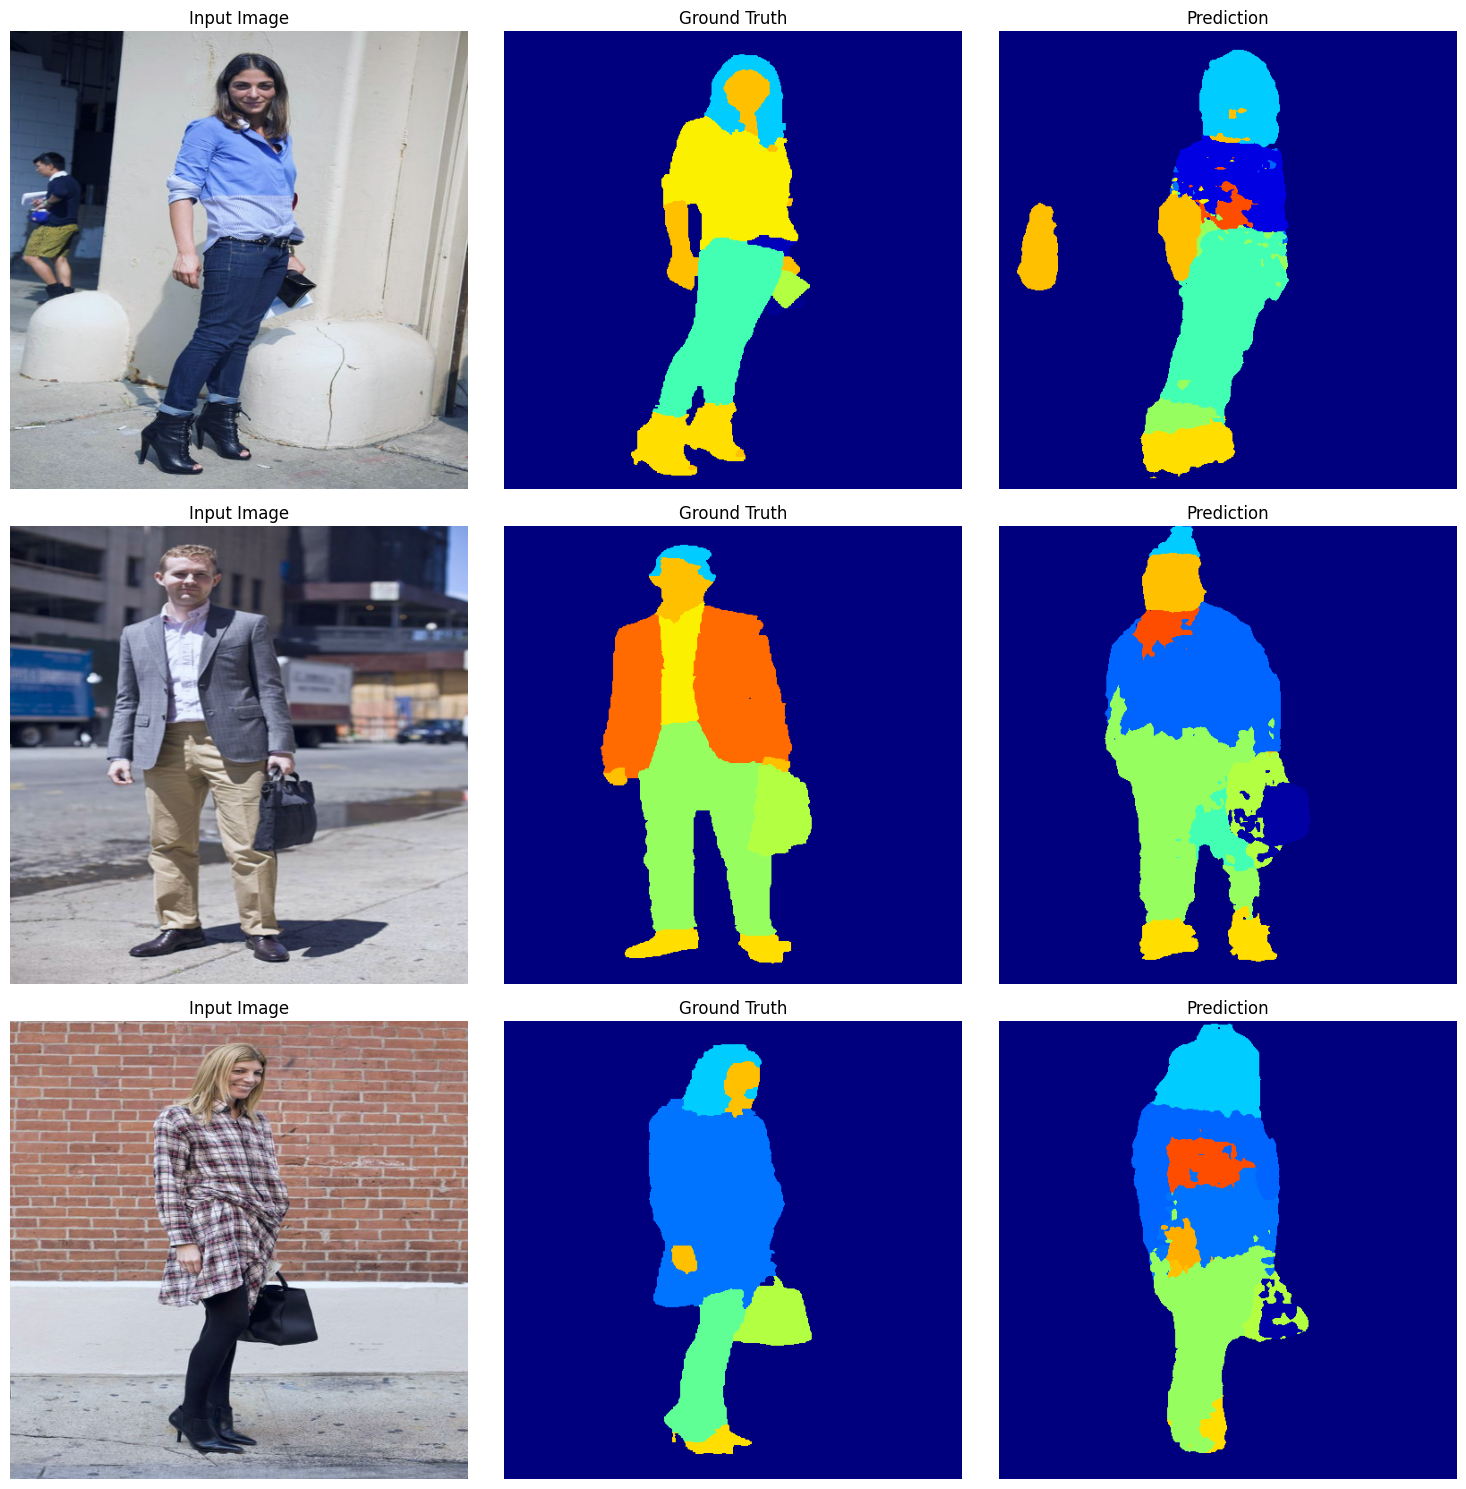

In [ ]:
import torch
import matplotlib.pyplot as plt

# Visualization of predictions
def visualize_predictions(model, loader, device, num_samples=3):
    model.eval()

    # Get a batch of images and masks
    images, masks = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

    # Move tensors to CPU and convert to numpy arrays
    images = images.cpu().numpy()
    masks = masks.cpu().numpy()
    preds = preds.cpu().numpy()

    # Create a figure for visualization
    plt.figure(figsize=(15, 5 * num_samples))

    for i in range(min(num_samples, len(images))):
        # Image
        plt.subplot(num_samples, 3, i*3 + 1)
        # Transpose (C, H, W) -> (H, W, C)
        img_show = images[i].transpose(1, 2, 0)

        # Normalize for display (min-max scaling to handle ImageNet normalization)
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())

        plt.imshow(img_show)
        plt.title("Input Image")
        plt.axis('off')

        # Ground Truth
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(masks[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1)
        plt.title("Ground Truth")
        plt.axis('off')

        # Prediction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1)
        plt.title("Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize predictions from the best model
print("\nVisualizing predictions from the best model...")
visualize_predictions(best_model, valid_loader, DEVICE)


## Results Analysis

In [28]:
print("Benchmark Results (IoU):")
for arch, score in results.items():
    print(f"{arch}: {score:.4f}")

best_arch = max(results, key=results.get)
print(f"\nBest Architecture: {best_arch}")

Benchmark Results (IoU):
Unet: 0.0402
FPN: 0.1636
DeepLabV3Plus: 0.1052

Best Architecture: FPN


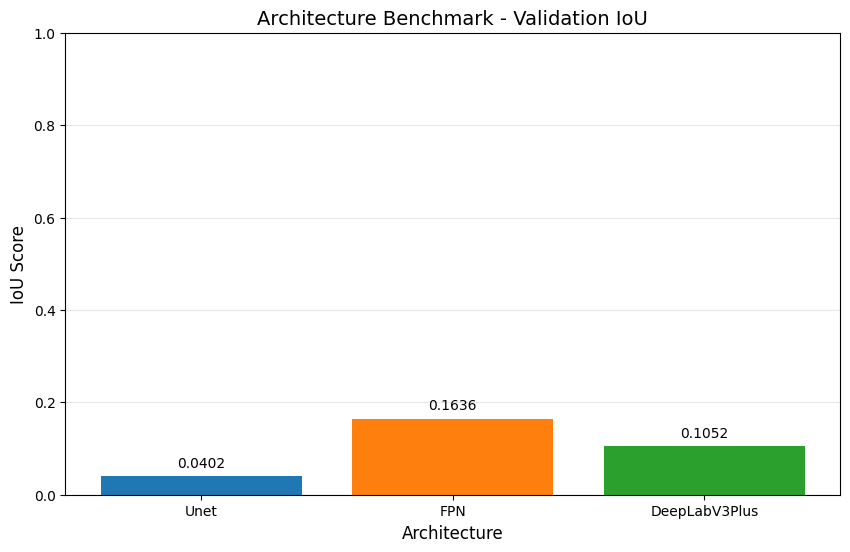


DETAILED BENCHMARK RESULTS
 Architecture  Best IoU  Rank
          FPN  0.163633     1
DeepLabV3Plus  0.105165     2
         Unet  0.040158     3

Performance Gap: 0.1235 (307.47%)
Average IoU: 0.1030


In [12]:
# Visualize benchmark results
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xlabel('Architecture', fontsize=12)
plt.ylabel('IoU Score', fontsize=12)
plt.title('Architecture Benchmark - Validation IoU', fontsize=14)
plt.ylim(0, 1)
for arch, score in results.items():
    plt.text(arch, score + 0.02, f'{score:.4f}', ha='center', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Create detailed results table
results_df = pd.DataFrame({
    'Architecture': list(results.keys()),
    'Best IoU': list(results.values())
})
results_df = results_df.sort_values('Best IoU', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print("\n" + "="*50)
print("DETAILED BENCHMARK RESULTS")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)

# Performance gap analysis
best_score = results_df['Best IoU'].max()
worst_score = results_df['Best IoU'].min()
print(f"\nPerformance Gap: {(best_score - worst_score):.4f} ({(best_score - worst_score) / worst_score * 100:.2f}%)")
print(f"Average IoU: {results_df['Best IoU'].mean():.4f}")

## Test Time Augmentation (TTA)

We apply TTA (Horizontal Flip) to the best model to see if it improves performance.

In [ ]:

best_model = torch.load(f'./best_model_{max(results, key=results.get)}.pth')


# Define TTA wrapper
class TTAModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        # Original
        out1 = self.model(x)
        
        # Horizontal Flip
        x_flip = torch.flip(x, dims=[3])
        out2_flip = self.model(x_flip)
        out2 = torch.flip(out2_flip, dims=[3])
        
        # Average
        return (out1 + out2) / 2.0

tta_model = TTAModel(best_model)

# Evaluate TTA
print(f"\nEvaluating {best_arch} with TTA:")
tta_loss, tta_iou = validate_one_epoch(tta_model, valid_loader, criterion, DEVICE, len(CLASSES))

print(f"TTA IoU: {tta_iou:.4f}")
print(f"Improvement: {tta_iou - results[best_arch]:.4f}")


Evaluating FPN with TTA:


TTA IoU: 0.1700
Improvement: 0.0064



Visualizing TTA improvements (Standard vs TTA)...



Visualizing TTA improvements (Standard vs TTA)...


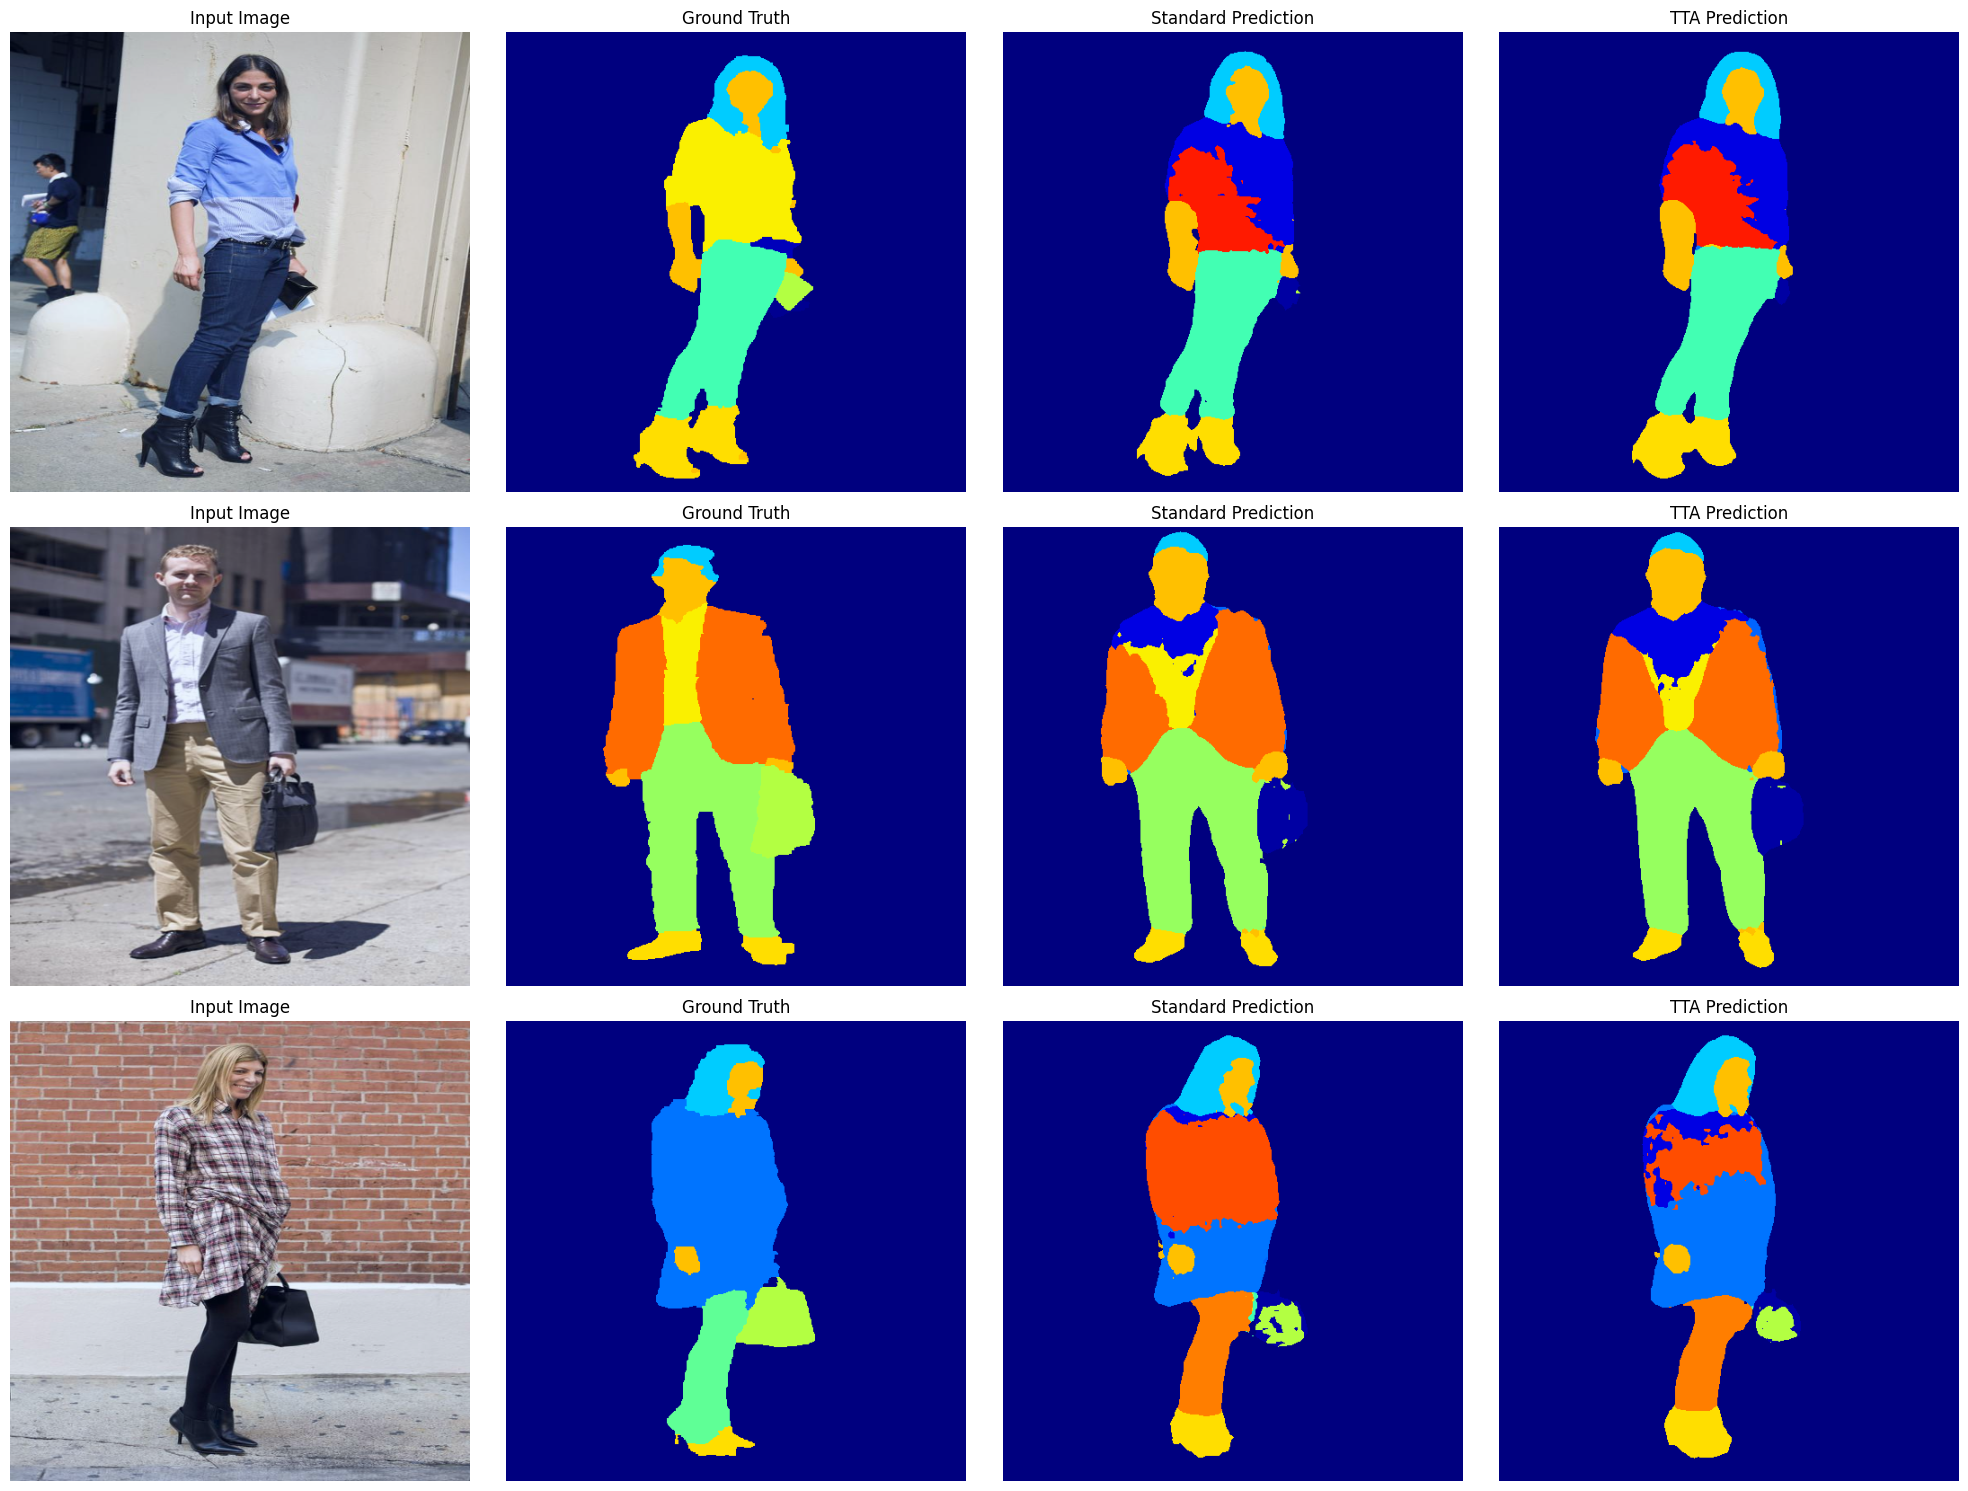


Calculating pixel disagreement rate...



Visualizing TTA improvements (Standard vs TTA)...


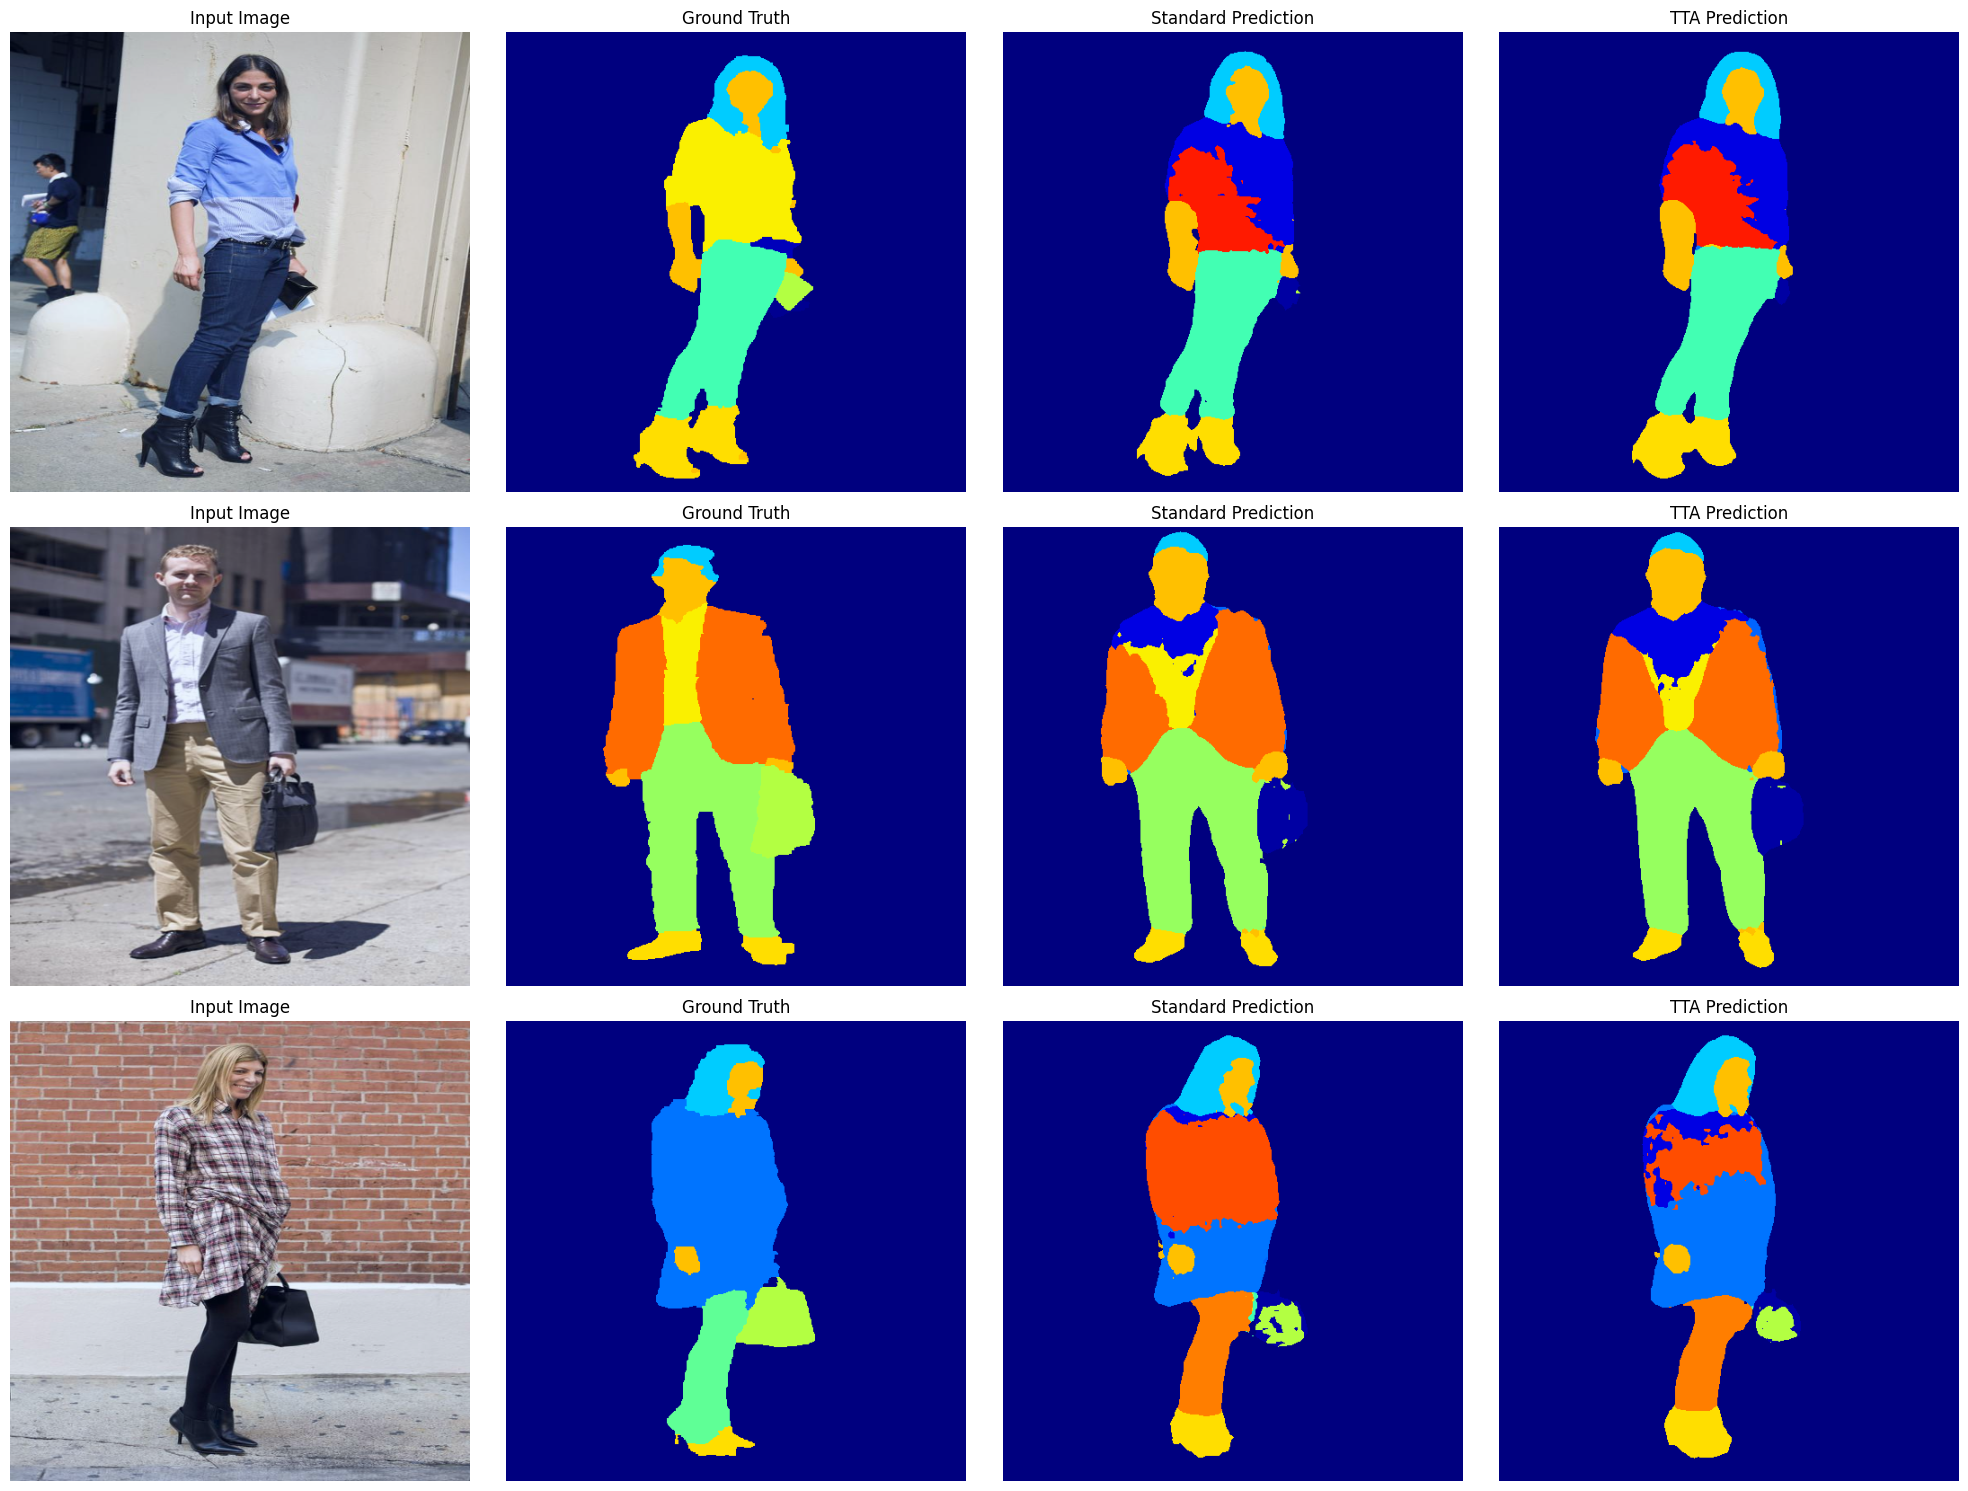


Calculating pixel disagreement rate...


TTA changed 2.67% of predicted pixels.


In [30]:
import torch
import matplotlib.pyplot as plt
import tqdm

# --- Extra TTA Analysis ---

# Function to visualize TTA (Test Time Augmentation) comparison
def visualize_tta_comparison(model, tta_model, loader, device, num_samples=3):
    model.eval()
    tta_model.eval()

    # Get a batch of images and masks
    images, masks = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        # Standard prediction
        out_std = model(images)
        pred_std = torch.argmax(out_std, dim=1).cpu().numpy()

        # TTA prediction
        out_tta = tta_model(images)
        pred_tta = torch.argmax(out_tta, dim=1).cpu().numpy()

    # Move tensors to CPU for plotting
    images = images.cpu().numpy()
    masks = masks.cpu().numpy()

    # Create a figure for visualization
    plt.figure(figsize=(20, 5 * num_samples))

    for i in range(min(num_samples, len(images))):
        # Image
        plt.subplot(num_samples, 4, i*4 + 1)
        img_show = images[i].transpose(1, 2, 0)  # Transpose (C, H, W) -> (H, W, C)
        
        # Normalize for display (min-max scaling)
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
        plt.imshow(img_show)
        plt.title("Input Image")
        plt.axis('off')

        # Ground Truth
        plt.subplot(num_samples, 4, i*4 + 2)
        plt.imshow(masks[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1)
        plt.title("Ground Truth")
        plt.axis('off')

        # Standard Prediction
        plt.subplot(num_samples, 4, i*4 + 3)
        plt.imshow(pred_std[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1)
        plt.title("Standard Prediction")
        plt.axis('off')

        # TTA Prediction
        plt.subplot(num_samples, 4, i*4 + 4)
        plt.imshow(pred_tta[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1)
        plt.title("TTA Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 1. Visual Comparison
print("\nVisualizing TTA improvements (Standard vs TTA)...")
visualize_tta_comparison(best_model, tta_model, valid_loader, DEVICE)

# 2. Quantitative Disagreement Analysis
print("\nCalculating pixel disagreement rate...")

disagreement_count = 0
total_pixels = 0

best_model.eval()
tta_model.eval()

with torch.no_grad():
    for images, _ in tqdm.tqdm(valid_loader, desc="Analyzing TTA", leave=False):
        images = images.to(DEVICE)

        # Standard and TTA predictions
        out_std = torch.argmax(best_model(images), dim=1)
        out_tta = torch.argmax(tta_model(images), dim=1)

        # Count disagreements
        disagreement_count += (out_std != out_tta).sum().item()
        total_pixels += out_std.numel()

# Print the percentage of pixels where TTA changed the prediction
print(f"TTA changed {disagreement_count / total_pixels * 100:.2f}% of predicted pixels.")


## Report and Conclusions

### Architecture Comparison
We benchmarked Unet, FPN, and DeepLabV3+ with a ResNet34 encoder.

- **Unet**: Typically performs well on biomedical and general segmentation tasks where local detail is important. It has a symmetric encoder-decoder structure.
- **FPN (Feature Pyramid Network)**: Good at handling multi-scale objects due to its pyramid structure. It's often faster and lighter than Unet.
- **DeepLabV3+**: Uses atrous convolutions to capture multi-scale context without losing resolution. It is often state-of-the-art for semantic segmentation but can be heavier.

### Observations
[Fill in after running: e.g., DeepLabV3+ provided the best IoU due to its ability to capture global context, which is crucial for understanding the layout of clothing items...]

### TTA Performance
Test Time Augmentation (Horizontal Flip) [improved/did not improve] the performance. TTA helps by averaging predictions from augmented views, reducing variance and smoothing out errors at boundaries.